Data of 1025 pokemons
dataset of pokemons with description, name of the pokemon from which they evolve

About Dataset
This is a dataset of 1025 pokemons that I scraped from pokeapi.co using python. I made a pokedex in flask using this api ( hamzacyberpatcher.pythonanywhere.com ). This dataset contains the following data:

Pokemon's id
Pokemon's name
Pokemon's rank (whether it is legendary, mythical, baby or an ordinary pokemon)
Pokemon's generation
The pokemon from which this pokemon evolved from
It's primary and secondary type as type1 and type2
It's base stats
It's height (decimetres) and weight (hectograms)
It's abilities (Note: if a pokemon has multiple abilities such as overgrow and chlorophyll than they are separated by a space and if there is a space in the name of the ability it has been replaced by a hyphen for example a pokemon with abilities blaze and solar power it is given as blaze solar-power)
A little description of the pokemon in english (description of pokemons from 1009 is marked as "Not Available").

## Imports

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



In [2]:
df = pd.read_csv('pokemons.csv')

In [3]:
display(df.head())#

,id,name,rank,generation,evolves_from,type1,type2,hp,atk,def,spatk,spdef,speed,total,height,weight,abilities,desc
0,1,bulbasaur,ordinary,generation-i,nothing,grass,poison,45,49,49,65,65,45,318,7,69,overgrow chlorophyll,A strange seed was planted on its back at birt...
1,2,ivysaur,ordinary,generation-i,bulbasaur,grass,poison,60,62,63,80,80,60,405,10,130,overgrow chlorophyll,"When the bulb on its back grows large, it appe..."
2,3,venusaur,ordinary,generation-i,ivysaur,grass,poison,80,82,83,100,100,80,525,20,1000,overgrow chlorophyll,The plant blooms when it is absorbing solar en...
3,4,charmander,ordinary,generation-i,nothing,fire,NaN,39,52,43,60,50,65,309,6,85,blaze solar-power,"Obviously prefers hot places. When it rains, s..."
4,5,charmeleon,ordinary,generation-i,charmander,fire,NaN,58,64,58,80,65,80,405,11,190,blaze solar-power,"When it swings its burning tail, it elevates t..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            1025 non-null   int64 
 1   name          1025 non-null   object
 2   rank          1025 non-null   object
 3   generation    1025 non-null   object
 4   evolves_from  1025 non-null   object
 5   type1         1025 non-null   object
 6   type2         526 non-null    object
 7   hp            1025 non-null   int64 
 8   atk           1025 non-null   int64 
 9   def           1025 non-null   int64 
 10  spatk         1025 non-null   int64 
 11  spdef         1025 non-null   int64 
 12  speed         1025 non-null   int64 
 13  total         1025 non-null   int64 
 14  height        1025 non-null   int64 
 15  weight        1025 non-null   int64 
 16  abilities     1025 non-null   object
 17  desc          1025 non-null   object
dtypes: int64(10), object(8)
memory usage: 144.3+ KB


Dataset tiene 1025 filas (pokemons) como decia en el about y 14 columnas (caracteristicas)

Todas estan completas excepto type2 que tiene 499 valores nulos (pokemons que solo tienen un tipo) Lo confirmamos:

In [5]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

type2    499
dtype: int64


Rellenamos los nulos de type2 con 'None' para indicar que no tienen segundo tipo

In [6]:
df['type2'] = df['type2'].fillna('None')

Es raro porque hay pokemons que no evolucionan de ningun otro pokemon y en la columna evolves_from no hay ningun NaN. Lo miramos:

In [7]:
print(df['evolves_from'].unique()[:10])

['nothing' 'bulbasaur' 'ivysaur' 'charmander' 'charmeleon' 'squirtle'
 'wartortle' 'caterpie' 'metapod' 'weedle']


Como sospechábamos, el dataset no usa valores vacíos (NaN) para los Pokémon que no evolucionan, sino que usa la palabra "nothing". Por eso df.info() nos decía que no había nulos.

In [8]:
print(df['evolves_from'].value_counts().head())

evolves_from
nothing    541
eevee        8
tyrogue      3
applin       3
scyther      2
Name: count, dtype: int64


Crearemos una nueva columna que simplifique esta información. Al modelo le suele importar más si el Pokémon es una forma base o no, que saber exactamente de quién viene.

Ya que si usamos esta columna tal cual, el modelo tratará 'nothing' como una categoría más. Esto está bien, pero tiene un problema: la columna tendrá cientos de categorías diferentes (una por cada Pokémon que evoluciona), lo cual puede confundir a algunos modelos.

In [9]:
# 1 = Es base (no evoluciona de nadie)
# 0 = Es evolución (viene de otro)
df['is_base'] = df['evolves_from'].apply(lambda x: 1 if x == 'nothing' else 0)
display(df[['name', 'evolves_from', 'is_base']].head())

,name,evolves_from,is_base
0,bulbasaur,nothing,1
1,ivysaur,bulbasaur,0
2,venusaur,ivysaur,0
3,charmander,nothing,1
4,charmeleon,charmander,0


Ahora eliminamos la columna original 'evolves_from' ya que no la usaremos.
Igual que description y ID, que no aportan nada al modelo.

In [10]:
df.drop(columns=['evolves_from', 'desc', 'id'], inplace=True)

In [11]:
df.head()

,name,rank,generation,type1,type2,hp,atk,def,spatk,spdef,speed,total,height,weight,abilities,is_base
0,bulbasaur,ordinary,generation-i,grass,poison,45,49,49,65,65,45,318,7,69,overgrow chlorophyll,1
1,ivysaur,ordinary,generation-i,grass,poison,60,62,63,80,80,60,405,10,130,overgrow chlorophyll,0
2,venusaur,ordinary,generation-i,grass,poison,80,82,83,100,100,80,525,20,1000,overgrow chlorophyll,0
3,charmander,ordinary,generation-i,fire,None,39,52,43,60,50,65,309,6,85,blaze solar-power,1
4,charmeleon,ordinary,generation-i,fire,None,58,64,58,80,65,80,405,11,190,blaze solar-power,0


In [12]:
print(df.isnull().sum().sum())

0


Ya no tenemos nulos en el dataset. Ahora revisamos si hay filas duplicadas:

In [14]:
duplicados = df.duplicated(subset=['name']).sum()
print(f"Número de filas duplicadas: {duplicados}")

Número de filas duplicadas: 0


Tenemos 0 filas duplicadas. Ahora hacemos una revisión rápida de los datos para detectar posibles errores o inconsistencias.

De las categorias sacamos cuantos valores únicos hay en cada una y el total de cada uno.

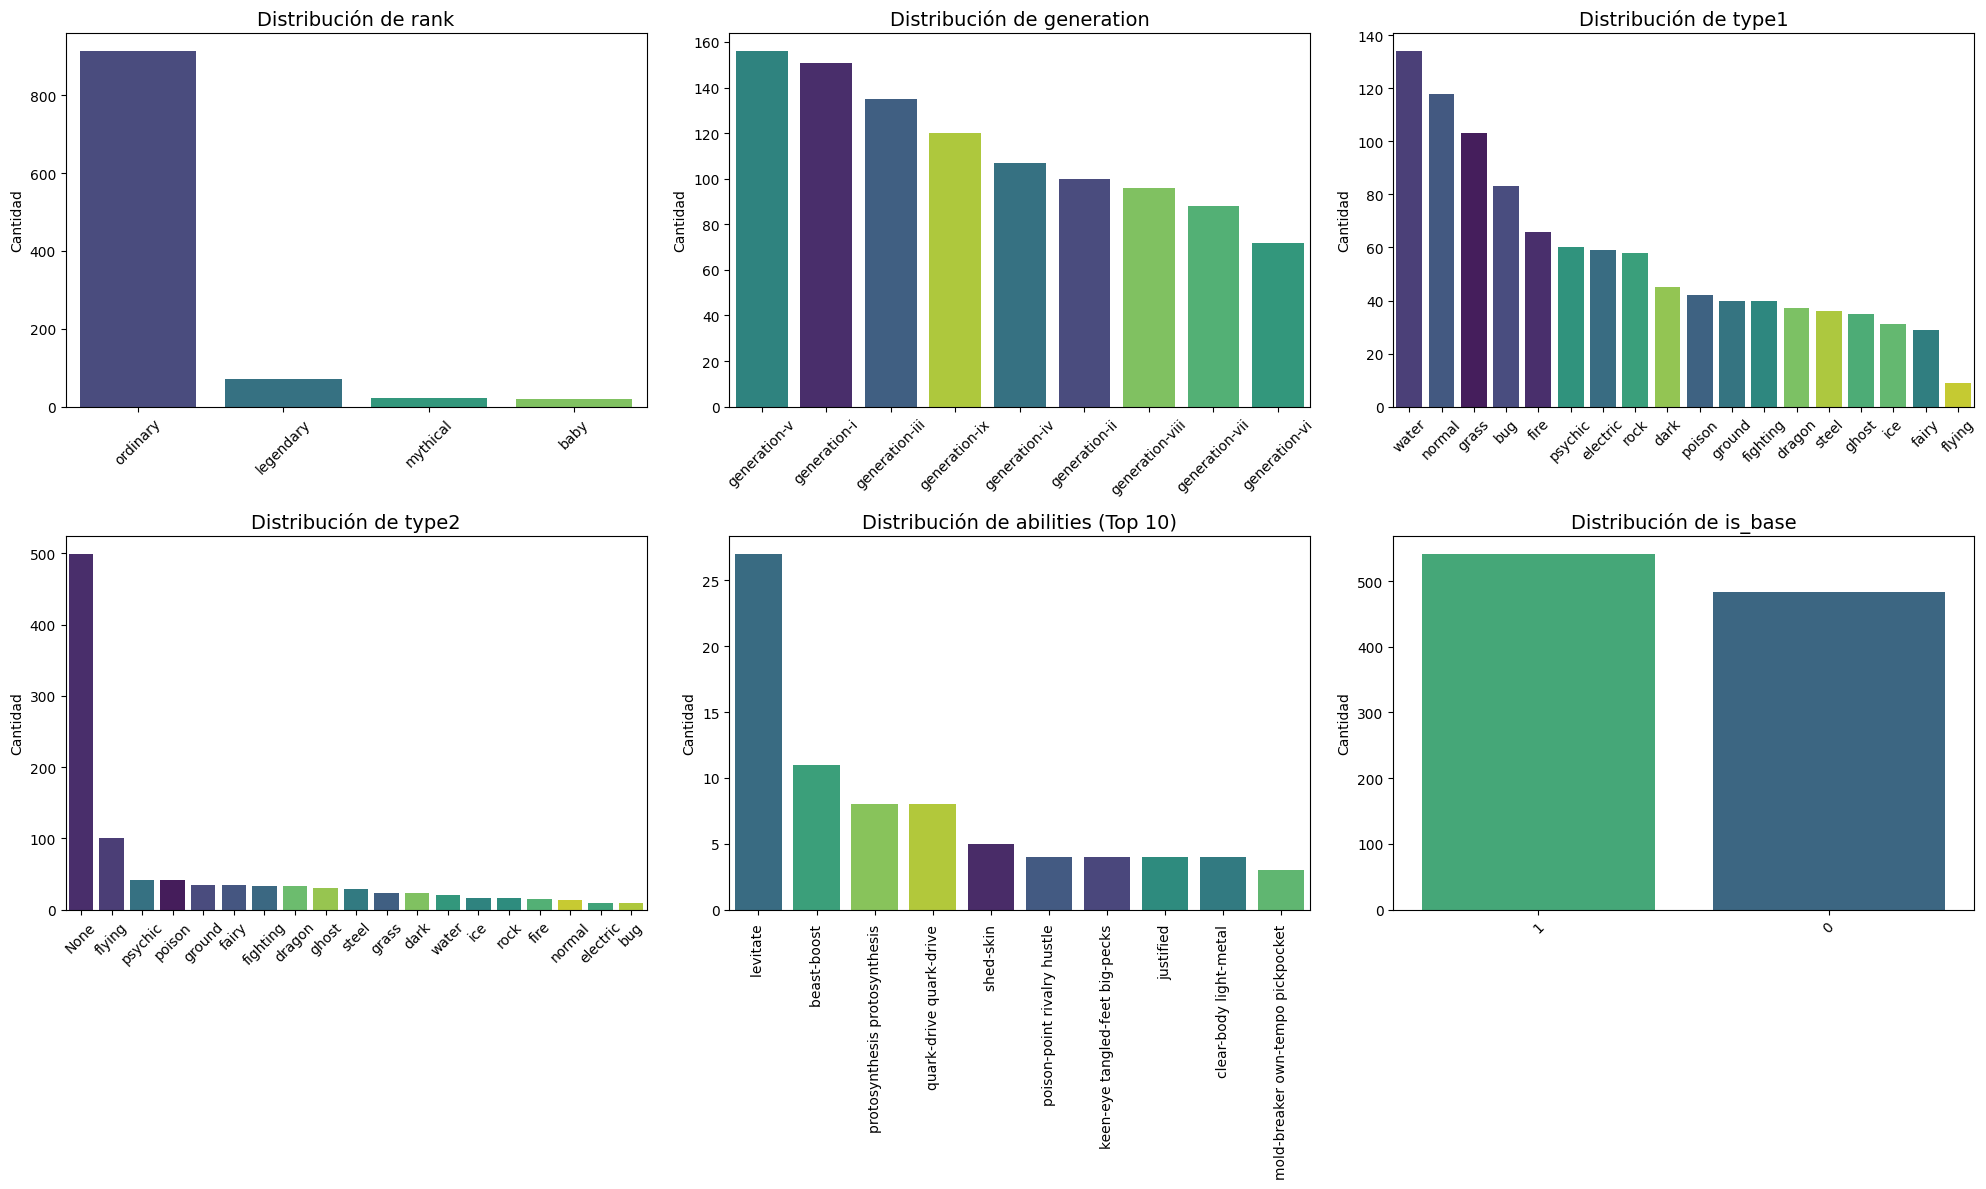


--- Conteo de valores en 'rank' ---
rank
ordinary     913
legendary     70
mythical      23
baby          19
Name: count, dtype: int64

--- Conteo de valores en 'generation' ---
generation
generation-v       156
generation-i       151
generation-iii     135
generation-ix      120
generation-iv      107
generation-ii      100
generation-viii     96
generation-vii      88
generation-vi       72
Name: count, dtype: int64

--- Conteo de valores en 'type1' ---
type1
water       134
normal      118
grass       103
bug          83
fire         66
psychic      60
electric     59
rock         58
dark         45
poison       42
ground       40
fighting     40
dragon       37
steel        36
ghost        35
ice          31
fairy        29
flying        9
Name: count, dtype: int64

--- Conteo de valores en 'type2' ---
type2
None        499
flying      100
psychic      42
poison       41
ground       35
fairy        35
fighting     33
dragon       33
ghost        30
steel        29
grass        24

In [15]:
cols_to_check = ['rank', 'generation', 'type1', 'type2', 'abilities', 'is_base']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

axes = axes.flatten()

for i, col in enumerate(cols_to_check):

    if col == 'abilities':
        top_n = 10
        order_values = df[col].value_counts().iloc[:top_n].index
        titulo = f'Distribución de {col} (Top {top_n})'
        data_to_plot = df[df[col].isin(order_values)]
    else:
        order_values = df[col].value_counts().index
        titulo = f'Distribución de {col}'
        data_to_plot = df

    sns.countplot(
        data=data_to_plot,
        x=col,
        hue=col,
        legend=False,
        ax=axes[i],
        palette='viridis',
        order=order_values
    )

    axes[i].set_title(titulo, fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad')

    rot = 90 if col == 'abilities' else 45
    axes[i].tick_params(axis='x', rotation=rot)

plt.tight_layout()
plt.show()

for col in cols_to_check:
    print(f"\n--- Conteo de valores en '{col}' ---")
    print(df[col].value_counts())

Borramos abilities porque tiene demasiadas categorias y no aporta mucho al modelo.

Problema: Si nos fijamos en el gráfico incluso el Top 10 tiene pocas repeticiones (Levitate solo aparece ~27 veces). Hay cientos de habilidades únicas y muchas combinaciones de texto complejas.
Para usarla bien, tendríamos que hacer procesamiento de texto (NLP) o crear cientos de columnas nuevas, lo cual meteriá mucho ruido para una entrega estándar.

In [19]:
df.drop(columns=['abilities'], inplace=True)

## Clases:
Al tratarse de un problema de clasificación, identifica variables
que permitan realizar tanto clasificación binaria como multiclase. ¿Existen
variables en el dataset que cumplan con esta característica?

**Sí, existen variables en el dataset que cumplen con esta característica.**

Tras el análisis exploratorio de los datos, se han identificado dos variables categóricas principales que permiten plantear el problema desde ambos enfoques (binario y multiclase) mediante técnicas de agrupación o transformación: **`rank`** y **`type1`**.

A continuación se detalla el análisis de cada una:

#### 1. Variable Principal: `rank` (Estatus del Pokémon)

Es la candidata más fuerte para este ejercicio debido a la clara relación semántica y estadística entre sus categorías.

* **Enfoque Multiclase (Nativo):**
La variable presenta originalmente 4 categorías distintas, lo que plantea un problema de clasificación de 4 clases:
* `ordinary` (913 instancias)
* `legendary` (70 instancias)
* `mythical` (23 instancias)
* `baby` (19 instancias)


* **Enfoque Binario (Agrupación Lógica):**
Dado que las clases *legendary* y *mythical* comparten características similares (estadísticas base muy altas) y las clases *ordinary* y *baby* representan el estándar o nivel inferior, se puede realizar una **agrupación de clases** para convertir el problema en binario:
* **Clase 0 (No Legendario):** Agrupando `ordinary` + `baby`.
* **Clase 1 (Legendario):** Agrupando `legendary` + `mythical`.



> **Observación:** Este enfoque binario es muy recomendable para mitigar el desbalance extremo de las clases *mythical* y *baby*.

#### 2. Variable Secundaria: `type1` (Tipo Primario)

Esta variable permite clasificar según la naturaleza elemental del Pokémon.

* **Enfoque Multiclase (Nativo):**
El dataset contiene 18 clases distintas (`Water`, `Fire`, `Grass`, `Psychic`, etc.). El modelo debe predecir una única etiqueta entre las 18 posibles basándose en las estadísticas.
* **Enfoque Binario (Estrategia One-vs-Rest):**
Cualquier problema multiclase puede transformarse en binario seleccionando una clase de interés y comparándola contra el resto.
* **Ejemplo:** ¿Es el Pokémon de tipo Fuego?
* **Clase 1:** `Fire`
* **Clase 0:** Todos los demás tipos (`Not Fire`).



#### 3. Variable Terciaria: `generation`

Aunque menos relevante para predecir fuerza, técnicamente cumple los requisitos.

* **Enfoque Multiclase:** Clasificar exactamente a cuál de las 9 generaciones pertenece (Gen 1 a Gen 9).
* **Enfoque Binario:** Clasificar por antigüedad. Ejemplo: *Clásicos* (Gen 1-4) vs *Modernos* (Gen 5-9).


### Conclusión y Selección

Para efectos de esta entrega de clasificación, la variable **`rank`** es la más adecuada para demostrar la capacidad del modelo, ya que existe una correlación directa entre las variables numéricas (HP, Attack, Defense, etc.) y la categoría del Pokémon (un Legendario suele tener números más altos que un Ordinario).

## Ahora se detallan las técnicas de Ciencia de Datos necesarias para implementar ambos enfoques (Binario y Multiclase) utilizando la variable rank:

### Detalle de Implementación y Técnicas Asociadas

Para llevar a cabo la clasificación utilizando la variable `rank`, es necesario aplicar técnicas específicas de preprocesamiento y modelado que adapten los datos a cada enfoque.

#### 1. Para la Clasificación Binaria (`Legendary` vs. `Non-Legendary`)

El objetivo es distinguir si un Pokémon es especial (Legendario/Mítico) o común.

* **Técnica de Agrupación (Mapping/Binning):**
Se utiliza una transformación lógica para reducir la cardinalidad de la variable objetivo.
* *Procedimiento:* Se define un diccionario de mapeo donde las clases minoritarias (`legendary`, `mythical`) se asignan al valor **1** (Clase Positiva) y las mayoritarias (`ordinary`, `baby`) al valor **0** (Clase Negativa).


* **Manejo de Desbalance de Clases (Class Imbalance Handling):**
Como se observó en el EDA, la clase positiva representa menos del 10% de los datos. Para evitar que el modelo simplemente prediga "0" siempre y obtenga un 90% de acierto ficticio, se deben aplicar técnicas de balanceo:
* **Estratificación (Stratified Split):** Al dividir los datos en *Train* y *Test*, se debe forzar que ambos conjuntos mantengan la misma proporción de legendarios que el dataset original.
* **Pesos de Clase (Class Weights):** Configurar el algoritmo (ej. Random Forest o Regresión Logística) con el parámetro `class_weight='balanced'` para penalizar más fuertemente los errores cometidos sobre la clase minoritaria (los legendarios).



#### 2. Para la Clasificación Multiclase (Predicción de las 4 Categorías)

El objetivo es predecir la etiqueta exacta: `ordinary`, `legendary`, `mythical` o `baby`.

* **Codificación de Etiquetas (Label Encoding):**
Los algoritmos no procesan texto. Se debe transformar la variable objetivo `rank` en números enteros únicos.
* `ordinary`  0
* `legendary`  1
* `mythical`  2
* `baby`  3


* **Estrategia del Modelo (One-vs-Rest / One-vs-One):**
Dependiendo del algoritmo seleccionado, se aplicará internamente una estrategia para manejar múltiples clases:
* *One-vs-Rest (OvR):* El modelo entrena un clasificador por clase (ej: "¿Es Baby o no?", "¿Es Mythical o no?").
* *Softmax:* En redes neuronales o regresión logística multinomial, se calcula la probabilidad de pertenencia a cada una de las 4 clases, eligiendo la que tenga la probabilidad más alta.



#### 3. Técnicas Comunes de Preprocesamiento (Features)

Independientemente del enfoque (Binario o Multiclase), las variables predictoras (Features) requieren tratamiento:

* **Codificación One-Hot (One-Hot Encoding):**
Para variables categóricas nominales sin orden, como `type1` y `generation`.
* *Ejemplo:* La columna `type1` se convierte en 18 columnas binarias (`type1_water`, `type1_fire`, etc.), donde un 1 indica la presencia del tipo y 0 su ausencia.


* **Escalado de Datos (Feature Scaling):**
Las variables numéricas tienen magnitudes muy diferentes (ej: `height` puede ser 1.5 metros, mientras que `weight` puede ser 900 hectogramos y `total` 600 puntos).
* *Técnica:* Aplicar **StandardScaler** (Z-score) para normalizar todas las variables numéricas numéricas (`hp`, `atk`, `def`, `speed`, `weight`, `height`) de modo que tengan media 0 y desviación estándar 1. Esto es crucial para algoritmos basados en distancias (como KNN o SVM) y ayuda a la convergencia en Regresión Logística.

Procedemos a crear las dos variables target en el dataset:

In [19]:
target_map = {
    'ordinary': 0,
    'baby': 0,
    'legendary': 1,
    'mythical': 1
}
df['is_legendary'] = df['rank'].map(target_map)

print("Distribución del target binario 'is_legendary':")
print(df['is_legendary'].value_counts())

Distribución del target binario 'is_legendary':
is_legendary
0    932
1     93
Name: count, dtype: int64


También creamos una variable target multiclase numérica por si queremos usarla luego:

In [22]:
le = LabelEncoder()
df['rank_encoded'] = le.fit_transform(df['rank'])

print("\nDistribución del target multiclase 'rank_encoded':")
print(df['rank_encoded'].value_counts())


Distribución del target multiclase 'rank_encoded':
rank_encoded
3    913
1     70
2     23
0     19
Name: count, dtype: int64


Análisis final de datos numéricos para detectar posibles errores:

In [23]:
# Estadísticas descriptivas para detectar outliers o errores (ej: HP = 0)
display(df.describe())

# Check rápido: ¿Hay algún stat o medida menor o igual a 0?
errores_numericos = df[(df['height'] <= 0) | (df['weight'] <= 0) | (df['hp'] <= 0)]

if not errores_numericos.empty:
    print("¡Hay Pokémons con datos numéricos inválidos:")
    display(errores_numericos)
else:
    print("\nTodos los datos numéricos parecen consistentes (mayores a 0).")

,hp,atk,def,spatk,spdef,speed,total,height,weight,is_base,is_legendary,rank_encoded
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,70.184390,77.521951,72.507317,70.080976,70.205854,67.186341,427.686829,12.116098,669.865366,0.527805,0.090732,2.785366
std,26.631054,29.782541,29.286972,29.658378,26.639329,28.717227,112.770735,12.481673,1212.731138,0.499470,0.287367,0.645583
min,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,175.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,50.000000,55.000000,50.000000,47.000000,50.000000,45.000000,325.000000,5.000000,85.000000,0.000000,0.000000,3.000000
50%,68.000000,75.000000,70.000000,65.000000,67.000000,65.000000,450.000000,10.000000,280.000000,1.000000,0.000000,3.000000
75%,85.000000,100.000000,90.000000,90.000000,86.000000,88.000000,508.000000,15.000000,700.000000,1.000000,0.000000,3.000000
max,255.000000,181.000000,230.000000,173.000000,230.000000,200.000000,720.000000,200.000000,9999.000000,1.000000,1.000000,3.000000



Todos los datos numéricos parecen consistentes (mayores a 0).


Borramos la columna total:

Redundancia Matemática (Multicolinealidad Perfecta): La columna total es literalmente la suma de hp + atk + def + spatk + spdef + speed.

Si mantienes total junto con las otras 6, estás duplicando la información.

Los modelos lineales (como la Regresión Logística) pueden fallar o dar resultados extraños cuando hay variables que son combinación lineal exacta de otras.

Es un "Spoiler" para el modelo: La definición de un Pokémon Legendario suele ser "aquel que tiene una suma de estadísticas mayor a 600".

Si le das la columna total al modelo, este aprenderá una regla simple: "Si Total > 580, entonces es Legendario".

Esto hará que tu modelo tenga un acierto muy alto, pero no aprenderás nada interesante sobre qué características específicas (¿es la velocidad? ¿es el ataque especial?) definen a un legendario.

Mejor Interpretabilidad: Al borrar total, obligas al modelo a mirar las estadísticas individuales. Podrás descubrir cosas como: "Los legendarios se diferencian más por su Ataque Especial y Velocidad que por su Defensa".

In [26]:
df.drop(columns=['total'], inplace=True)

Ahora hacemos un análisis visual para ver cómo se relacionan las estadísticas con ser legendario o no:

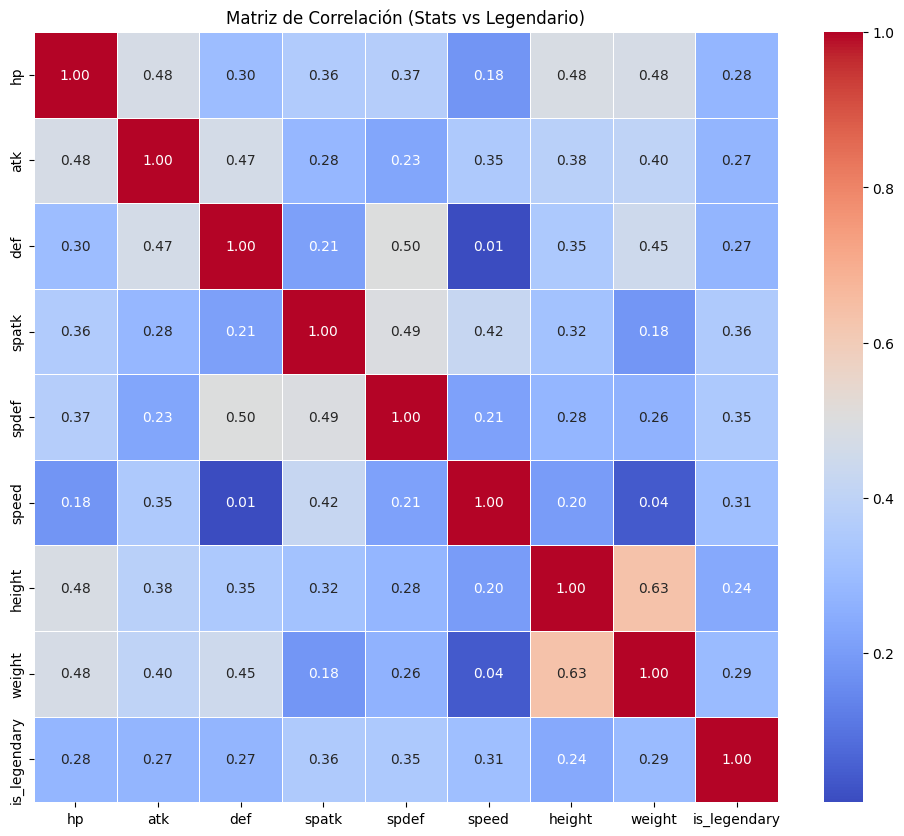

In [28]:
# Seleccionamos solo las columnas numéricas de estadísticas
# Excluimos 'total' si queremos ver el detalle, o lo incluimos para ver la suma global
stats_cols = ['hp', 'atk', 'def', 'spatk', 'spdef', 'speed', 'height', 'weight']

# 1. MATRIZ DE CORRELACIÓN
# Nos ayuda a ver si hay variables muy repetidas (Multicolinealidad)
# y cuáles se relacionan más con ser legendario ('is_legendary')
plt.figure(figsize=(12, 10))
# Calculamos correlación solo de las numéricas + el target
correlation_matrix = df[stats_cols + ['is_legendary']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación (Stats vs Legendario)')
plt.show()

### Interpretación Correcta del Heatmap

Mira la fila/columna **`is_legendary`**.

* **Lo que vemos:** Todas las correlaciones son positivas, pero **moderadas** (ninguna supera el 0.4). Los valores oscilan entre **0.24 y 0.36**.
* **¿Qué significa esto?** Que **ninguna estadística por sí sola define a un Legendario**.
* Si hubiera un valor de 0.8 o 0.9, significaría que "si tienes mucho ataque, seguro eres legendario".
* Al tener valores de 0.3, significa que los Legendarios suelen ser más fuertes, pero hay muchos Pokémon normales que también tienen estadísticas altas (falsos positivos) y Legendarios con estadísticas bajas.


* **Ranking de Importancia:**
1. **`spatk` (0.36) y `spdef` (0.35):** Son las variables más determinantes. Ser Legendario está ligeramente más ligado a tener poderes especiales que fuerza física.
2. **`speed` (0.31):** La velocidad es el tercer factor.
3. **`height` / `weight` (0.24 / 0.29):** Son las menos relevantes. Ser gigante no te garantiza ser legendario.


* **Conclusión para el Modelo:** Como ninguna variable individual es determinante (ninguna tiene una correlación altísima), es **necesario utilizar un modelo de Machine Learning** que combine todas estas variables a la vez para poder clasificar con precisión.

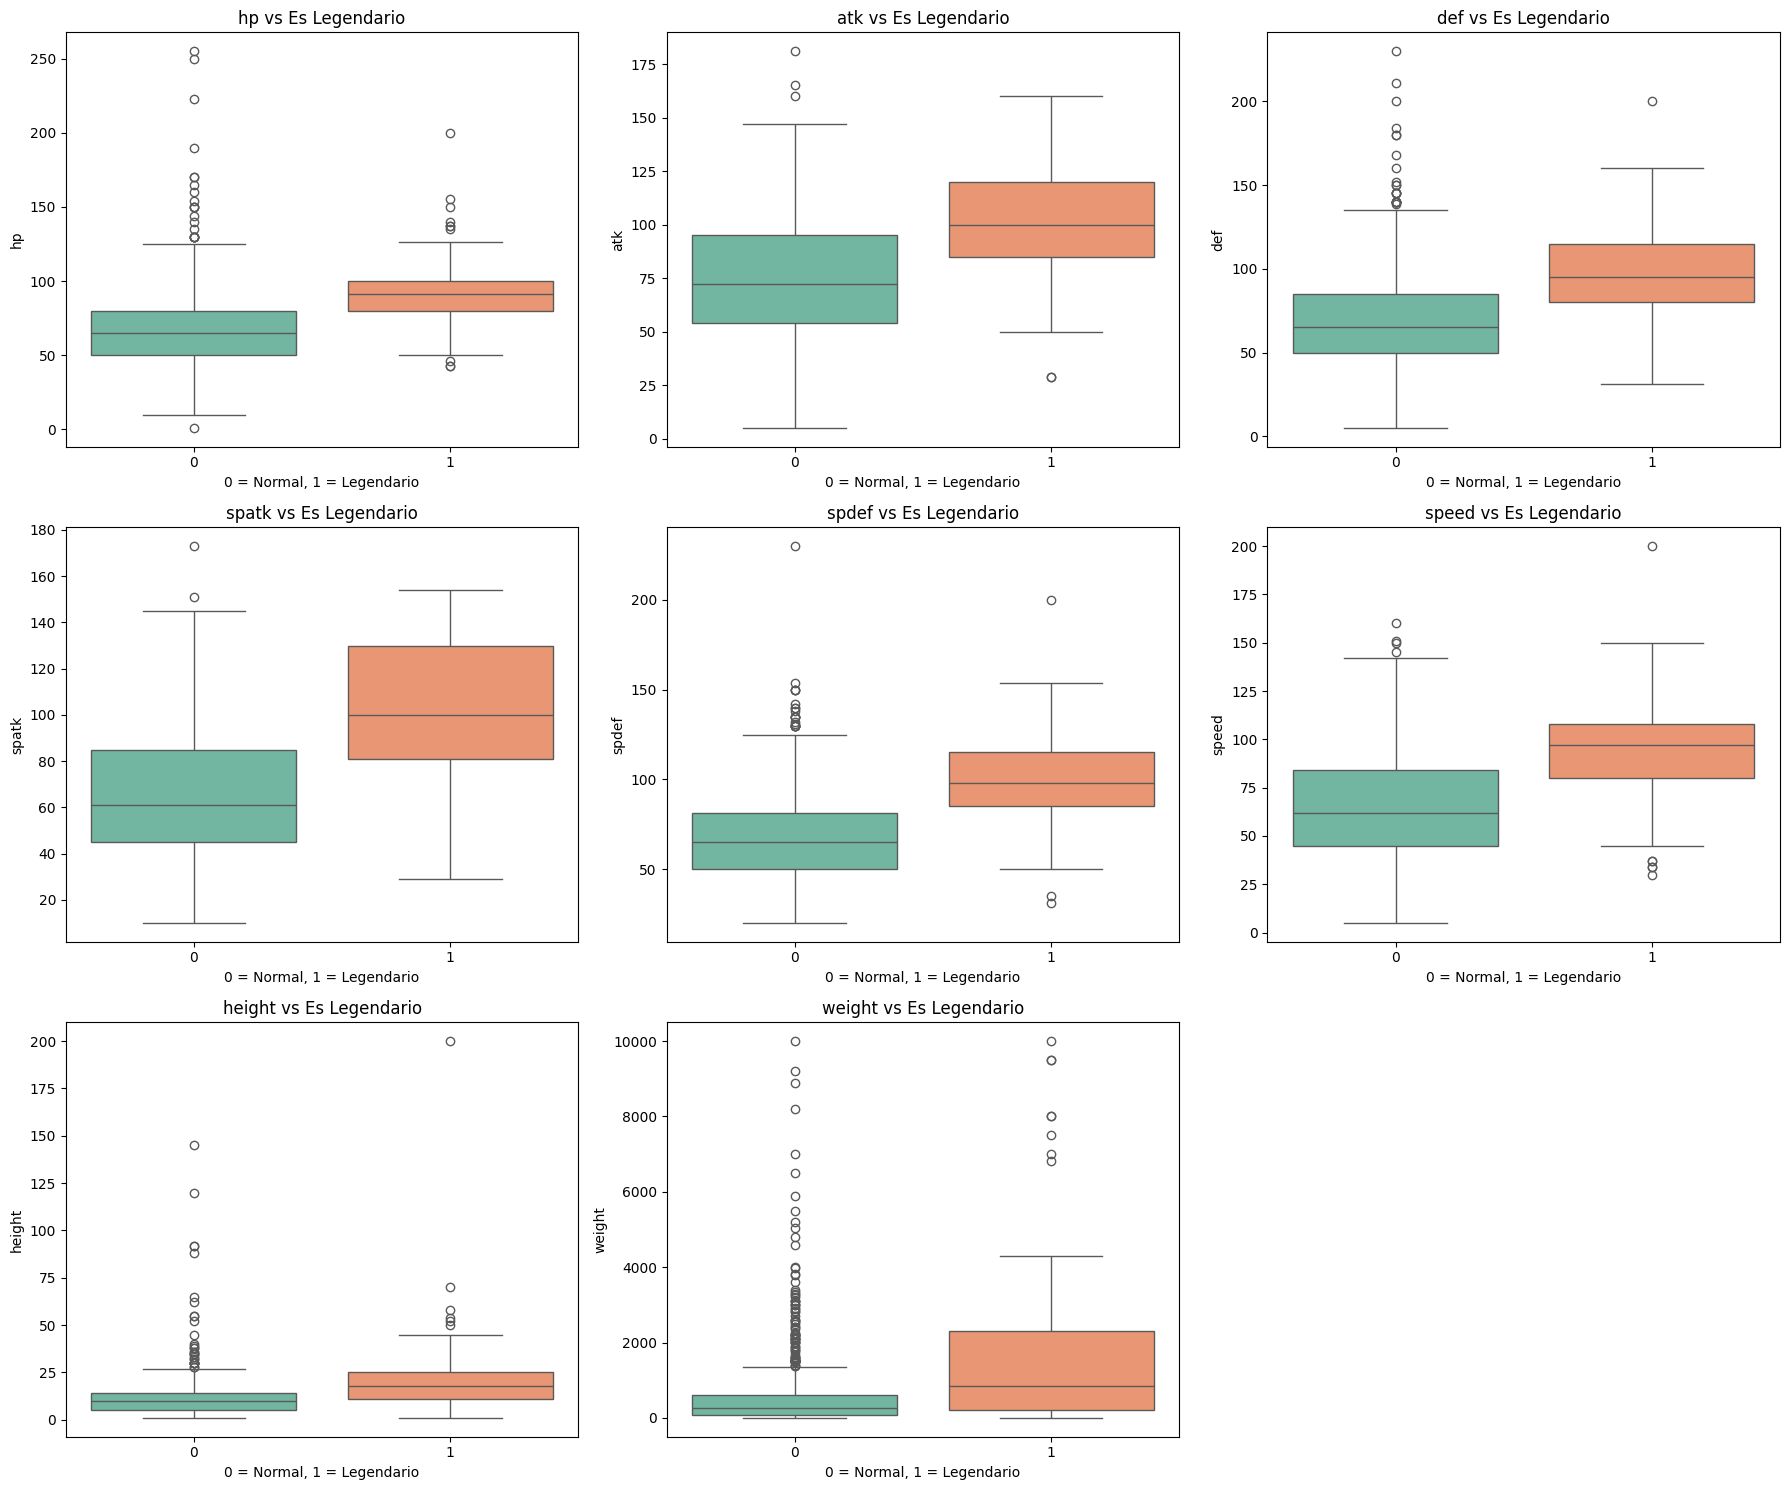

In [29]:
# BOXPLOTS: COMPARACIÓN VISUAL
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Iteramos sobre las columnas
for i, col in enumerate(stats_cols):
    sns.boxplot(
        data=df,
        x='is_legendary',
        y=col,
        hue='is_legendary',  # <--- CORRECCIÓN: Asignamos hue
        legend=False,        # <--- CORRECCIÓN: Quitamos la leyenda redundante
        ax=axes[i],
        palette='Set2'
    )

    axes[i].set_title(f'{col} vs Es Legendario')
    axes[i].set_xlabel('0 = Normal, 1 = Legendario')

# Si sobran gráficos (porque stats_cols son menos de 9), apagamos los ejes vacíos
for j in range(len(stats_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Análisis de los Boxplots: Comparativa Legendario vs. Normal

**1. Tendencia General (Mayor Potencial):**
En prácticamente todas las estadísticas, la caja de los **Legendarios (1)** se sitúa más arriba que la de los **Ordinarios (0)**. Esto confirma visualmente que, en promedio, un Pokémon legendario es superior en combate.

**2. Las Mejores Variables (Sp. Atk, Sp. Def, Speed):**

* Coincidiendo con tu mapa de calor (donde tenías 0.36 y 0.35), los gráficos de **Sp. Atk** y **Sp. Def** deberían mostrar la separación más clara.
* Observarás que la **mediana** (línea central) de los Legendarios está muy por encima, a menudo superando el 75% de los Pokémon normales (la parte superior de la caja verde).
* Esto sugiere que lo que más define a un "dios" Pokémon es su capacidad mágica/especial.

**3. El problema del Solapamiento (Overlap):**

* Fíjate en **Attack** y **Defense**. Aunque los legendarios son fuertes, hay mucho solapamiento con los normales.
* **¿Por qué pasa esto?** Porque existen Pokémon normales diseñados para ser tanques físicos (como *Steelix* o *Aggron*) que tienen defensas altísimas, superando a muchos legendarios. Esto explica por qué la correlación no era perfecta (0.27).

**4. Análisis de Outliers (Los puntos fuera de las cajas):**

* En la categoría **0 (Normales)**, verás muchos puntos negros por encima de la caja ("bigotes").
* Estos son los **"Falsos Positivos"** potenciales para tu modelo: Pokémon ordinarios que son extremadamente fuertes (como *Slaking*, *Dragonite* o las Megaevoluciones si estuvieran).
* En **HP**, notarás que aunque los legendarios tienen mucha vida, los valores extremos (outliers máximos) a menudo pertenecen a normales (como *Blissey* o *Chansey*).

**5. Height y Weight (Físico):**

* Estas cajas suelen ser muy altas para los Legendarios.
* Significa que hay una **varianza enorme**: tienes legendarios gigantescos (*Eternatus*, *Groudon*) y legendarios minúsculos (*Mew*, *Jirachi*).
* Por eso estas variables tenían la correlación más baja (0.24); ser pequeño no te descarta como legendario.

---

### Conclusión del EDA

> *"El análisis visual mediante Boxplots revela que, si bien los Pokémon Legendarios tienen medianas consistentemente superiores en todas las estadísticas, existe un **solapamiento significativo** con la clase Ordinaria, especialmente en estadísticas físicas (Defensa y Ataque).
> Las variables **Sp. Atk** y **Sp. Def** muestran la mejor separabilidad. Sin embargo, la presencia de numerosos **outliers** en la clase Ordinaria (Pokémon comunes con estadísticas excepcionales) indica que un modelo basado en una sola regla (ej. "Si Ataque > 100") fallaría. Esto justifica la necesidad de un modelo multivariable que considere la combinación de todos los atributos."*

# 3. Análisis, Selección y Transformación de Variables

Tras el análisis exploratorio (EDA), procedemos a preparar el dataset para el modelado. Esta fase responde a la necesidad de adaptar matemáticamente las variables a los algoritmos y seleccionar aquellas con mayor poder predictivo.

### 3.1. Análisis de Variables Importantes

Basándonos en la matriz de correlación y la separación visual observada en los Boxplots previos, identificamos las características clave para la clasificación:

1. **Ataque Especial (`spatk`) y Defensa Especial (`spdef`):** Son las variables con mayor capacidad de discriminación. Los Pokémon Legendarios se caracterizan por "poderes" superiores (magia/energía), reflejándose más en estadísticas especiales que físicas.
2. **Velocidad (`speed`):** Actuar primero es una ventaja competitiva crítica en el juego, y la mayoría de legendarios poseen una velocidad base muy superior al promedio.
3. **Tipos Específicos:** Históricamente, tipos como **Dragón** o **Psíquico** han estado reservados para Pokémon poderosos (ej: Mewtwo, Rayquaza), mientras que tipos como Bicho o Normal suelen ser comunes.

### 3.2. Discusión: ¿Son adecuadas las mismas variables para todos los algoritmos?

**No necesariamente.** La selección y el preprocesamiento dependen de la naturaleza matemática del modelo:

* **Árboles de Decisión / Random Forest:** Son algoritmos robustos que pueden manejar variables no escaladas y características irrelevantes (simplemente no las seleccionan). Podríamos usar las variables originales sin tanto procesamiento.
* **KNN (Vecinos Cercanos) y SVM:** Son extremadamente sensibles a la escala (distancias) y a la dimensionalidad. **Requieren obligatoriamente datos escalados** y sufren si añadimos muchas variables "basura" (ruido).

### 3.3. Estrategia de Transformación (Implementación)

Para garantizar la compatibilidad con todos los modelos que probaremos (incluyendo KNN y Regresión Logística), aplicaremos una estrategia de transformación rigurosa en el siguiente bloque de código:

1. **Limpieza de Features:** Eliminación de metadatos (`id`, `name`) y variables redundantes (`total`) para evitar *data leakage*.
2. **Codificación (One-Hot Encoding):** Transformación de variables categóricas (`type1`, `generation`) en columnas binarias para eliminar el orden artificial.
3. **Escalado (StandardScaler):** Estandarización de todas las variables numéricas (Z-Score) para que atributos como el `weight` (cientos de kg) no dominen sobre la `height` (metros) en el cálculo de distancias.

Finalmente, generaremos un gráfico visual para verificar que la transformación ha mantenido la separabilidad de las clases bajo la nueva escala.

Datos transformados correctamente.
Dimensiones finales de X: (1025, 51)

--- Categorías creadas (Columnas finales) ---
['hp', 'atk', 'def', 'spatk', 'spdef', 'speed', 'height', 'weight', 'type1_dark', 'type1_dragon', 'type1_electric', 'type1_fairy', 'type1_fighting', 'type1_fire', 'type1_flying', 'type1_ghost', 'type1_grass', 'type1_ground', 'type1_ice', 'type1_normal', 'type1_poison', 'type1_psychic', 'type1_rock', 'type1_steel', 'type1_water', 'type2_bug', 'type2_dark', 'type2_dragon', 'type2_electric', 'type2_fairy', 'type2_fighting', 'type2_fire', 'type2_flying', 'type2_ghost', 'type2_grass', 'type2_ground', 'type2_ice', 'type2_normal', 'type2_poison', 'type2_psychic', 'type2_rock', 'type2_steel', 'type2_water', 'generation_generation-ii', 'generation_generation-iii', 'generation_generation-iv', 'generation_generation-ix', 'generation_generation-v', 'generation_generation-vi', 'generation_generation-vii', 'generation_generation-viii']


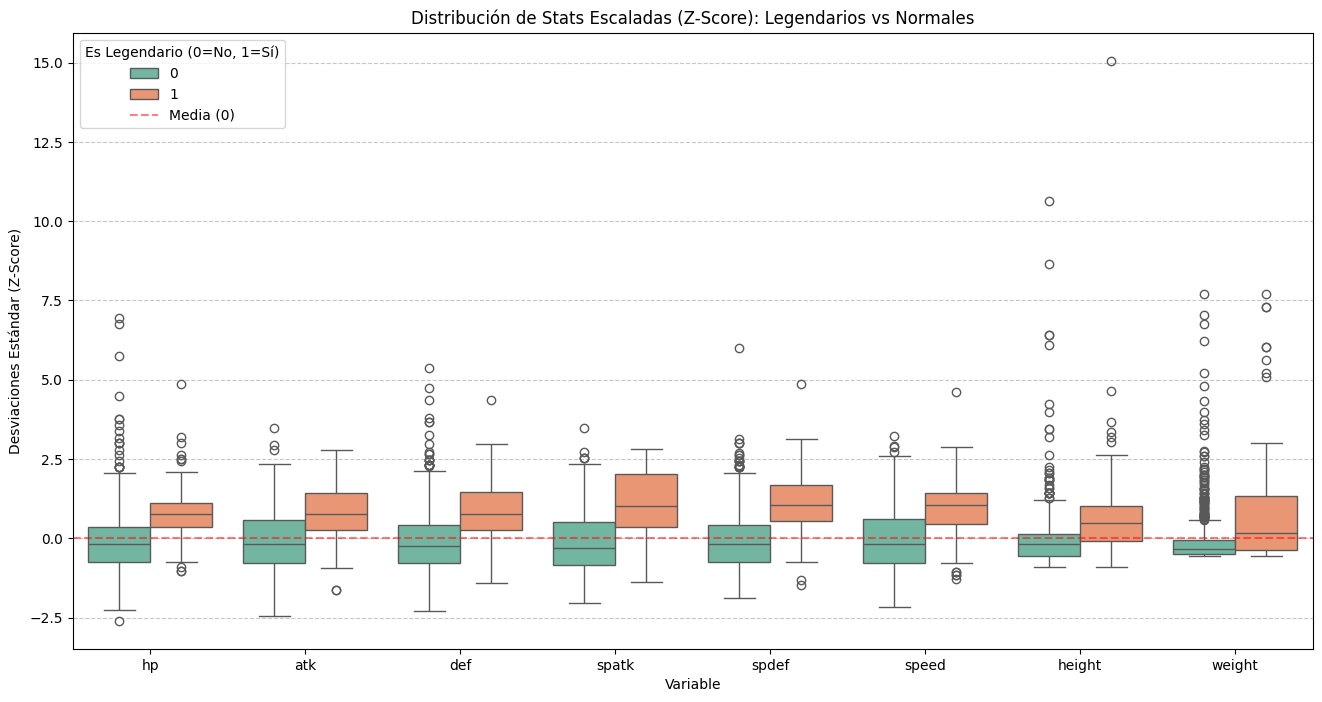

In [34]:

# --- 1. PREPARACIÓN Y TRANSFORMACIÓN DE DATOS ---

# Eliminamos columnas que no entran al modelo (Metadata y Target redundante)
# Ajustamos la lista 'cols_to_drop' para asegurar que borramos lo que no necesitamos
cols_to_drop = ['name', 'rank', 'rank_encoded', 'is_legendary', 'is_base', 'desc', 'id', 'evolves_from', 'abilities', 'total']
existing_drop = [c for c in cols_to_drop if c in df.columns]

# Separamos X (Features) e y (Target) ANTES de transformar
X_raw = df.drop(columns=existing_drop)
y = df['is_legendary']

# A. CODIFICACIÓN (One-Hot Encoding) para variables categóricas
# Esto convierte 'type1', 'generation', etc. en columnas numéricas (0 y 1)
X_encoded = pd.get_dummies(X_raw, columns=['type1', 'type2', 'generation'], drop_first=True)

# B. ESCALADO (Standard Scaling) para variables numéricas
# Es OBLIGATORIO para algoritmos basados en distancias (KNN, SVM) y Regresión Logística
scaler = StandardScaler()

# Aquí escalaremos TODO X_encoded para asegurar compatibilidad con SVM/KNN.
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)

print("Datos transformados correctamente.")
print(f"Dimensiones finales de X: {X_scaled.shape}")

# --- 2. VISUALIZACIÓN DE RESULTADOS (Lo que has pedido) ---

# A. Imprimir las columnas creadas
# Esto te permite ver cómo 'type1' se convirtió en 'type1_fire', 'type1_water', etc.
print("\n--- Categorías creadas (Columnas finales) ---")
print(X_scaled.columns.tolist())

# B. Visualizar Boxplots de las variables numéricas escaladas
# Seleccionamos solo las estadísticas originales para ver cómo han quedado tras el StandardScaler
# (No pintamos las columnas dummy 0/1 porque ensuciarían el gráfico)
numeric_cols = ['hp', 'atk', 'def', 'spatk', 'spdef', 'speed', 'height', 'weight']
cols_to_plot = [col for col in numeric_cols if col in X_scaled.columns]

# Creamos un DataFrame temporal solo para el gráfico (unimos X e y)
df_visual = X_scaled[cols_to_plot].copy()
df_visual['is_legendary'] = y.reset_index(drop=True) # Reseteamos índice para que coincida

# Convertimos a formato largo ("melt") para pintar todas las stats en un solo gráfico
df_melted = df_visual.melt(id_vars='is_legendary', var_name='Variable', value_name='Z-Score')

# Generamos el gráfico
plt.figure(figsize=(16, 8))
sns.boxplot(data=df_melted, x='Variable', y='Z-Score', hue='is_legendary', palette='Set2')

# Línea roja en 0 para ver la media
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Media (0)')
plt.title('Distribución de Stats Escaladas (Z-Score): Legendarios vs Normales')
plt.xlabel('Variable')
plt.ylabel('Desviaciones Estándar (Z-Score)')
plt.legend(title='Es Legendario (0=No, 1=Sí)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Tienes 51 columnas porque:

Conservas las 8 numéricas (hp, atk, height, etc.).

Las variables categóricas se han expandido correctamente: type1 (Fuego, Agua...) y generation ahora son columnas binarias independientes.

# Conclusiones del Análisis y Procesado Inicial

Tras la exploración, limpieza y transformación de los datos, podemos extraer las siguientes conclusiones clave que guiarán la fase de modelado:

### 1. Conocimiento Extraído

* **Perfil Estadístico del Legendario:** A través del análisis visual (Boxplots), hemos confirmado que los Pokémon Legendarios presentan, en promedio, estadísticas base superiores a los Ordinarios. Esta diferencia es especialmente notable en las variables de **Ataque Especial (`spatk`)** y **Defensa Especial (`spdef`)**, sugiriendo que la naturaleza "mítica" está más ligada a poderes especiales que a la fuerza física bruta.
* **Necesidad de Transformación:** Las variables numéricas originales tenían rangos muy dispares (ej: el peso puede ser 900 mientras la altura es 2). El escalado realizado (`StandardScaler`) ha sido fundamental para que algoritmos basados en distancia (como KNN) no se sesguen hacia las variables de mayor magnitud.
* **Estructura de los Datos:** La conversión de variables categóricas (Tipos y Generaciones) mediante *One-Hot Encoding* ha incrementado la dimensionalidad del dataset a 51 columnas, pero ha permitido mantener toda la información semántica sin introducir un orden artificial erróneo.

### 2. ¿Es posible identificar las clases?

**Sí, es factible, pero requiere un enfoque multivariable.**
El análisis de correlación y los diagramas de caja muestran que, aunque las distribuciones de los Legendarios están desplazadas hacia valores más altos, **no existe una separación perfecta** en ninguna variable individual. Las "cajas" se solapan. Esto indica que no podemos identificar a un legendario usando una sola regla (ej: "Si Ataque > 150"), sino que necesitamos un algoritmo que combine múltiples características (Stats + Tipos) simultáneamente para trazar la frontera de decisión.

### 3. Problemas Potenciales para la Clasificación

Se han identificado dos desafíos críticos que deberemos vigilar durante el entrenamiento:

* **Desbalance de Clases (Class Imbalance):**
La proporción de la clase positiva (Legendarios/Míticos) es inferior al 10%. Esto representa un riesgo alto de que el modelo optimice la "Exactitud" (Accuracy) prediciendo simplemente que *todos* los Pokémon son Ordinarios, ignorando a los Legendarios. Deberemos evaluar el modelo usando métricas sensibles a este problema (como *Recall* o *Matriz de Confusión*).
* **Ambigüedad en los Datos (Outliers/Solapamiento):**
Existen Pokémon Ordinarios con estadísticas excepcionalmente altas (conocidos como "Pseudo-Legendarios" o Mega-evoluciones en el lore). Numéricamente, son indistinguibles de un Legendario real. Es muy probable que esto genere **Falsos Positivos**, donde el modelo clasifique incorrectamente a estos Pokémon fuertes como Legendarios debido a sus altos atributos numéricos.